In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../')

from pathlib import Path

import phys_ml.visualization.vertex_visualization as vertvis
import phys_ml.visualization.base as vis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

data_dir = Path('/gpfs/data/fs71925/shepp123/frgs_6d/')
rmse_df = pd.read_csv('reconstruction_results.csv')
classification_df = pd.read_pickle('classification_results.pkl')

plot_dir = Path('../../../../thesis/images/')

## contents

&emsp;0&emsp;on real space  
&emsp;1&emsp;trained on all vertices  
&emsp;&emsp;1-1&emsp;simple autoencoder  
&emsp;&emsp;1-2&emsp;contrastive autoencoder  
&emsp;2&emsp;trained on only 2 phases  
&emsp;&emsp;2-1&emsp;exclude SC-phase  
&emsp;&emsp;&emsp;2-1-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-1-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-2&emsp;exclude AFM-phase  
&emsp;&emsp;&emsp;2-2-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-3&emsp;exclude FM-phase  
&emsp;&emsp;&emsp;2-3-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-3-2&emsp;contrastive autoencoder  
&emsp;3&emsp;trained on only 1 phase  
&emsp;&emsp;3-1&emsp;SC-phase  
&emsp;&emsp;3-2&emsp;AFM-phase  
&emsp;&emsp;3-3&emsp;FM-phase  
&emsp;4&emsp;correlation  
&emsp;5&emsp;convergence  

## visualize vertex

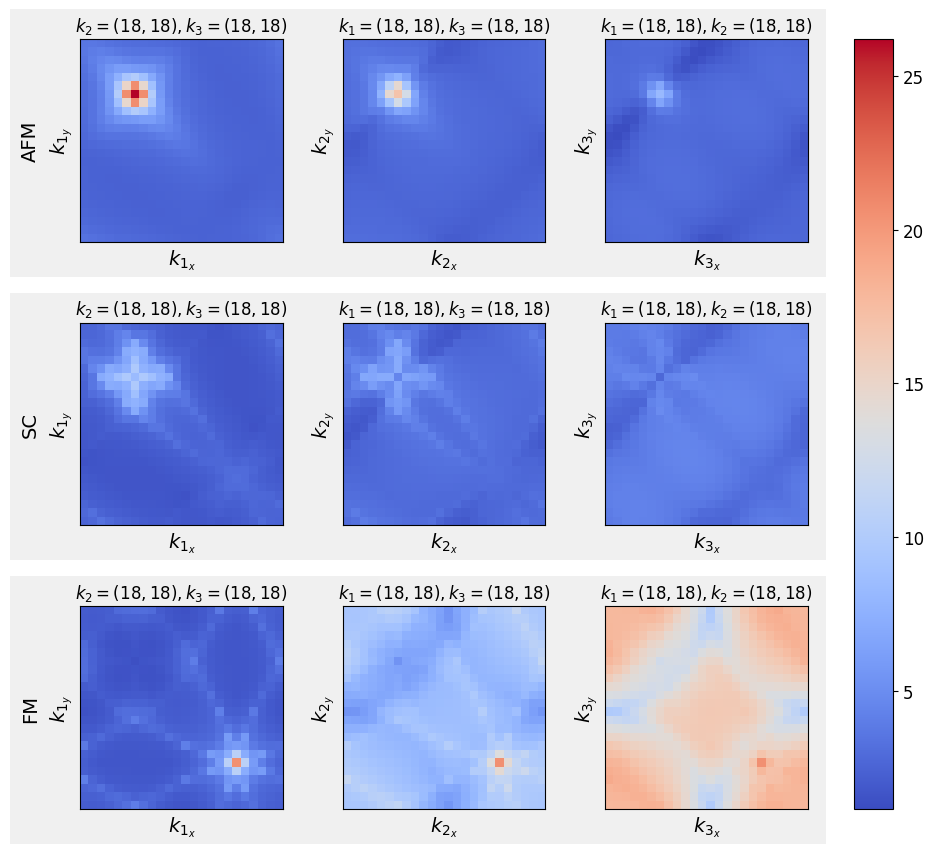

In [116]:
files_names = ['tp0.090000_mu0.360000', 'tp0.270000_mu1.080000', 'tp0.410000_mu1.640000']
vertices = [AutoEncoderVertex24x6Dataset.load_from_file(data_dir / f'{fn}.h5') for fn in files_names]
vertvis.plot_compare_slices(vertices, i=18, axis=3, vmin=None, vmax=None)

## vertex statistics

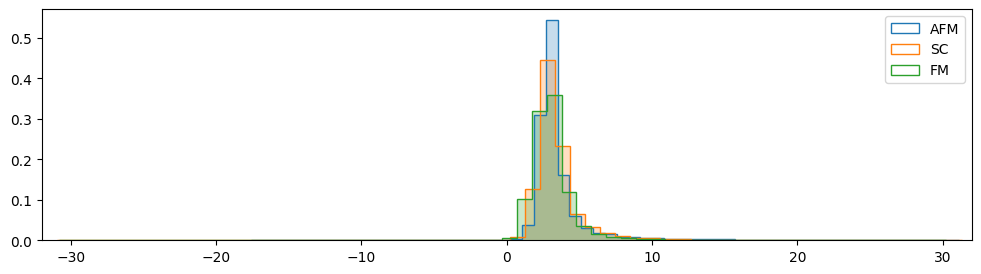

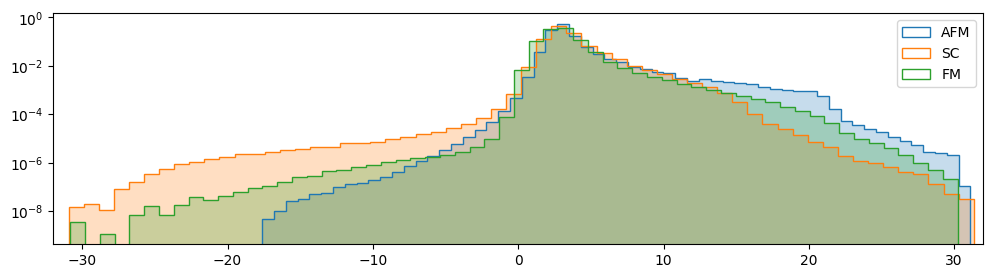

,min,max,mean,sum
AFM,-17.621026,31.116854,3.516467,13440147922.163141
SC,-30.943928,31.344199,3.435302,13129930305.072977
FM,-30.830774,30.236403,3.128338,11956693254.854389


In [3]:
df, data = verteval.vertex_statistics(data_dir)
verteval.plot_statistics(data)
verteval.plot_statistics(data, log=True)
df

## correlation

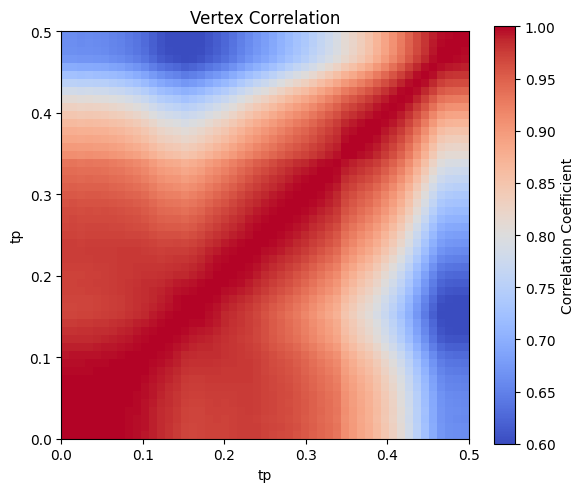

In [9]:
cor_mat = np.load(f'cor_mat_real.npy')
vertvis.plot_correlation(cor_mat, "Vertex Correlation", vmin=0.6)

In [10]:
cor_mat.min()

np.float64(0.5897979984026432)

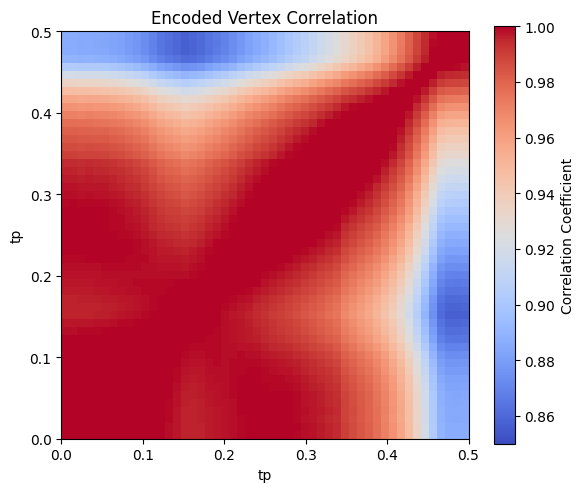

In [6]:
cor_mat = np.load(f'cor_mat_latent_1-1-ld32.npy')
vertvis.plot_correlation(cor_mat, "Encoded Vertex Correlation", vmin=0.85)

In [4]:
cor_mat.min()

np.float64(0.8568989038467407)

## compare autoencoder models

In [2]:
rmse_summary = rmse_df.drop(columns=['tp', 'train_data', 'contrastive', 'train_phase']).groupby(['run_id', 'ld', 's']).mean()
rmse_summary['test_rmse_train_phase'] = (rmse_df[~rmse_df['train_data'] & rmse_df['train_phase']]
                                            .drop(columns=['tp', 'train_data', 'contrastive', 'train_phase'])
                                            .groupby(['run_id', 'ld', 's']).mean())
rmse_summary['test_rmse_test_phase'] = (rmse_df[~rmse_df['train_data'] & ~rmse_df['train_phase']]
                                            .drop(columns=['tp', 'train_data', 'contrastive', 'train_phase'])
                                            .groupby(['run_id', 'ld', 's']).mean())
rmse_summary['train_rmse'] = (rmse_df[rmse_df['train_data']].drop(columns=['tp', 'train_data', 'contrastive', 'train_phase'])
                                                            .groupby(['run_id', 'ld', 's']).mean())
rmse_summary

rmse  test_rmse_train_phase  test_rmse_test_phase  \
run_id ld s                                                              
1_1    32 24000  0.007771                    NaN                   NaN   
1_2    32 24000  0.066215                    NaN                   NaN   
2_1_1  8  24000  0.169867               0.110327              0.273417   
       16 24000  0.097626               0.058324              0.168671   
       20 24000  0.074753               0.044556              0.137733   
       24 24000  0.046875               0.026416              0.093036   
       32 2000   0.068156               0.044921              0.110540   
          8000   0.040277               0.023146              0.077541   
          12000  0.047274               0.026910              0.090472   
          16000  0.018830               0.008657              0.045544   
          24000  0.023504               0.013406              0.047442   
2_1_2  32 24000  0.043141               0.024098              0.083902   
2_2_1  32 24000  0.011346               0.007191              0.016933   
2_2_2  32 24000  0.050307               0.049067              0.049049   
2_3_1  32 24000  0.024447               0.015248              0.035115   
2_3_2  32 24000  0.067075               0.047465              0.078320   
3_1    32 24000  0.016433               0.009049              0.018667   
3_2    32 24000  0.054052               0.012059              0.079995   
3_3    32 24000  0.019987               0.006524              0.026567   

                 train_rmse  
run_id ld s                  
1_1    32 24000    0.007771  
1_2    32 24000    0.066215  
2_1_1  8  24000    0.140872  
       16 24000    0.077321  
       20 24000    0.055514  
       24 24000    0.032327  
       32 2000     0.055987  
          8000     0.028698  
          12000    0.033985  
          16000    0.009967  
          24000    0.015824  
2_1_2  32 24000    0.030556  
2_2_1  32 24000    0.007874  
2_2_2  32 24000    0.051612  
2_3_1  32 24000    0.019538  
2_3_2  32 24000    0.064569  
3_1    32 24000    0.010156  
3_2    32 24000    0.014287  
3_3    32 24000    0.008324

In [17]:
rs = rmse_summary.reset_index()
rs = rs.merge(rmse_df[['run_id', 'ld', 's', 'contrastive']].drop_duplicates(), on=['run_id', 'ld', 's'])
# rs = rs.rename(columns={'run_id': 'scenario', 'rmse': 'RMSE (all)', 'train_rmse': 'RMSE (train)',
#                         'test_rmse_train_phase': 'RMSE (test vertices from train phase)', 'test_rmse_test_phase': 'RMSE (test phase)'})
rs = rs[['run_id', 'ld', 's', 'contrastive', 'rmse', 'test_rmse_train_phase', 'test_rmse_test_phase']]

print(rs[~rs['contrastive'] & (rs['ld'] == 32) & (rs['s'] == 24000)]
        .drop(columns=['ld', 's', 'contrastive'])
        .to_latex(index=False, float_format="%.3f"))

print(rs[rs['contrastive'] & (rs['ld'] == 32) & (rs['s'] == 24000)]
        .drop(columns=['ld', 's', 'contrastive'])
        .to_latex(index=False, float_format="%.3f"))

print(rs[(rs['run_id'] == '2_1_1') & (rs['s'] == 24000)]
        .drop(columns=['s', 'contrastive'])
        .to_latex(index=False, float_format="%.3f"))

print(rs[(rs['run_id'] == '2_1_1') & (rs['ld'] == 32)]
        .drop(columns=['ld', 'contrastive'])
        .to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lrrr}
\toprule
run_id & rmse & test_rmse_train_phase & test_rmse_test_phase \\
\midrule
1_1 & 0.008 & NaN & NaN \\
2_1_1 & 0.024 & 0.013 & 0.047 \\
2_2_1 & 0.011 & 0.007 & 0.017 \\
2_3_1 & 0.024 & 0.015 & 0.035 \\
3_1 & 0.016 & 0.009 & 0.019 \\
3_2 & 0.054 & 0.012 & 0.080 \\
3_3 & 0.020 & 0.007 & 0.027 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrr}
\toprule
run_id & rmse & test_rmse_train_phase & test_rmse_test_phase \\
\midrule
1_2 & 0.066 & NaN & NaN \\
2_1_2 & 0.043 & 0.024 & 0.084 \\
2_2_2 & 0.050 & 0.049 & 0.049 \\
2_3_2 & 0.067 & 0.047 & 0.078 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrr}
\toprule
run_id & ld & rmse & test_rmse_train_phase & test_rmse_test_phase \\
\midrule
2_1_1 & 8 & 0.170 & 0.110 & 0.273 \\
2_1_1 & 16 & 0.098 & 0.058 & 0.169 \\
2_1_1 & 20 & 0.075 & 0.045 & 0.138 \\
2_1_1 & 24 & 0.047 & 0.026 & 0.093 \\
2_1_1 & 32 & 0.024 & 0.013 & 0.047 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrr}
\toprule
run_id & s & rmse & test_rmse_train

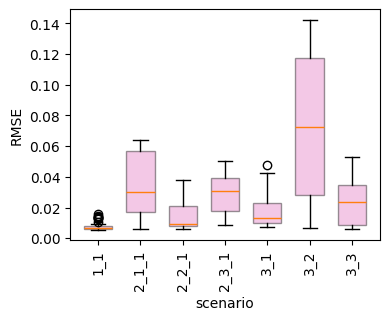

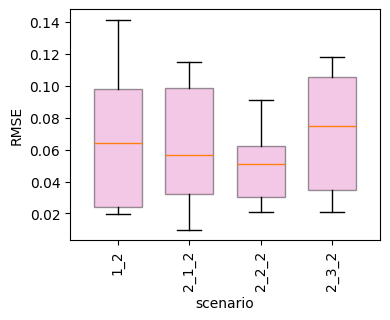

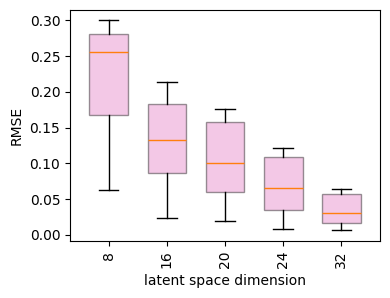

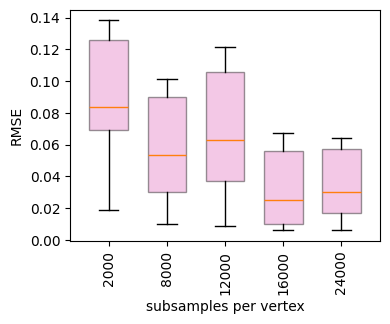

In [21]:
verteval.plot_rmse_boxplots(rmse_df, figsize=(4, 3), train_data=False)

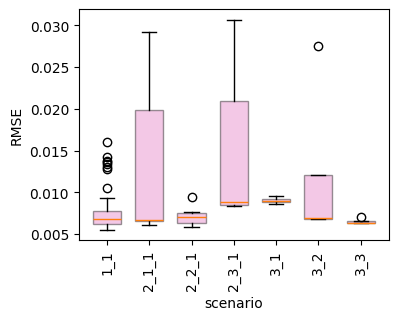

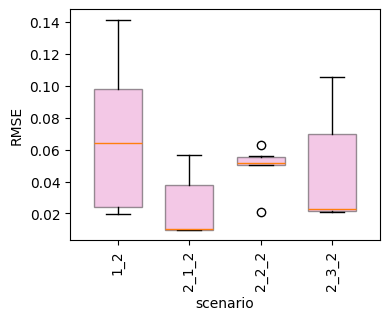

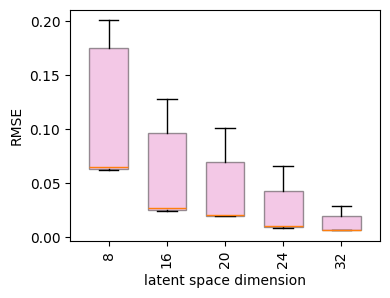

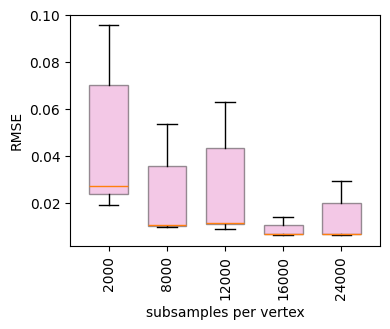

In [25]:
# train vertices only
df = rmse_df.copy()
df = df[df['run_id'].str.startswith('1_') | (~df['train_data'] & df['train_phase'])]
verteval.plot_rmse_boxplots(df, figsize=(4, 3), train_data=False, plot_dir=plot_dir, plot_name='ae_res1')

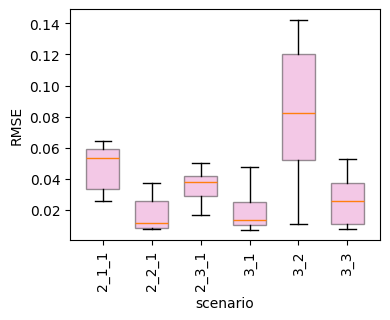

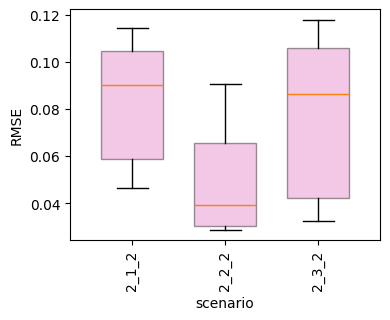

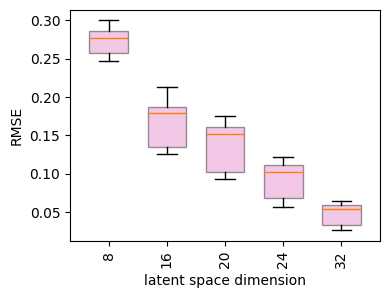

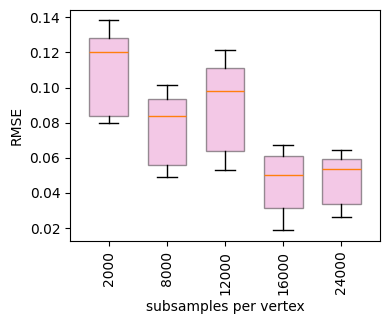

In [ ]:
# test vertices only
df = rmse_df.copy()
df = df[~df['train_data'] & ~df['train_phase']]
verteval.plot_rmse_boxplots(df, figsize=(4, 3), train_data=False, plot_dir=plot_dir, plot_name='ae_res2')

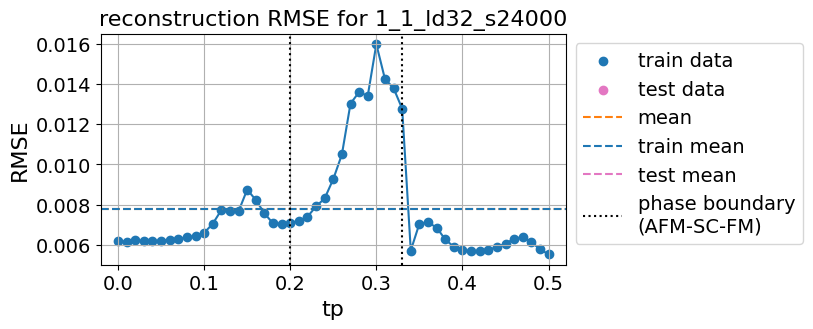

reconstruction RMSE for 1_1_ld32_s24000
mean: 0.007771204776818385, min: 0.0055337100284298, max: 0.0159865485509519
training data only - mean: 0.007771204776818385, min: 0.0055337100284298, max: 0.0159865485509519


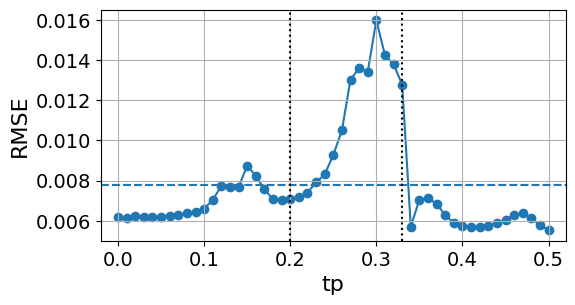

reconstruction RMSE for 2_1_1_ld32_s24000
mean: 0.023504360896572443, min: 0.0054835548049802, max: 0.06428741514296
training data only - mean: 0.01582447853219828, min: 0.0054835548049802, max: 0.0501498918183749
test data only - mean: 0.03447562141710695, min: 0.0060597556595962, max: 0.06428741514296


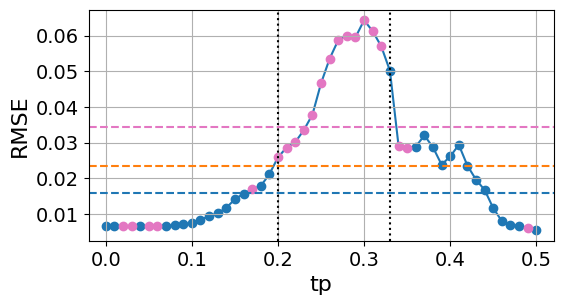

reconstruction RMSE for 2_2_1_ld32_s24000
mean: 0.011346324672715713, min: 0.0058296047811714, max: 0.0376805900382426
training data only - mean: 0.007874428499352064, min: 0.0058585200357042, max: 0.0126556805233798
test data only - mean: 0.014684686377873067, min: 0.0058296047811714, max: 0.0376805900382426


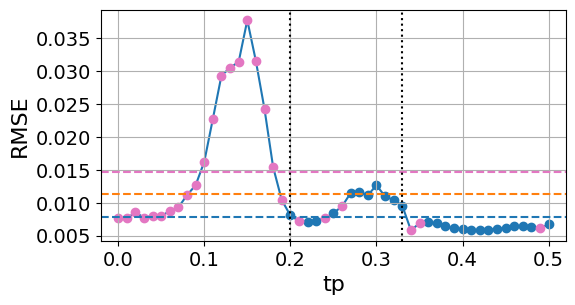

reconstruction RMSE for 2_3_1_ld32_s24000
mean: 0.024446766145674214, min: 0.008417594942537, max: 0.0501274356605866
training data only - mean: 0.019537599560778503, min: 0.0084585091309584, max: 0.0412011397862826
test data only - mean: 0.029552299393965753, min: 0.008417594942537, max: 0.0501274356605866


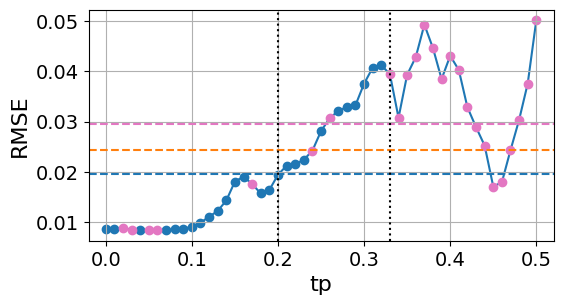

reconstruction RMSE for 3_1_ld32_s24000
mean: 0.016432640288140465, min: 0.0073222943543964, max: 0.0475276224161039
training data only - mean: 0.01015621203985333, min: 0.0085851273079696, max: 0.0117938620285331
test data only - mean: 0.01796347644625928, min: 0.0073222943543964, max: 0.0475276224161039


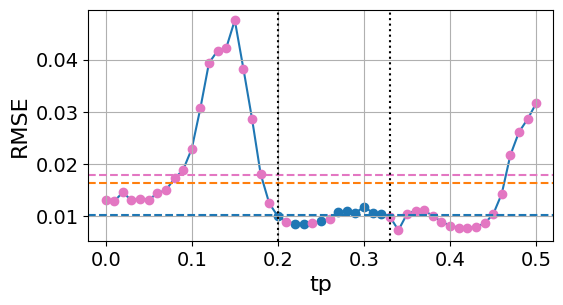

reconstruction RMSE for 3_2_ld32_s24000
mean: 0.05405205146477475, min: 0.0068304631837742, max: 0.1423498029275165
training data only - mean: 0.01428682297744393, min: 0.0069133213537977, max: 0.035640568504099
test data only - mean: 0.07223044163041169, min: 0.0068304631837742, max: 0.1423498029275165


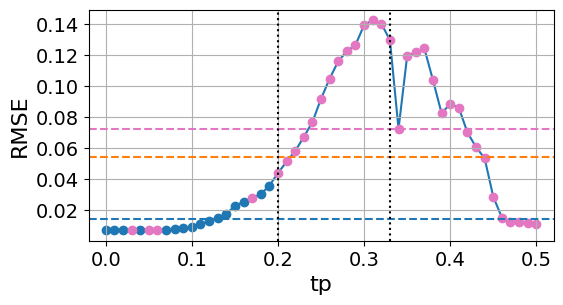

reconstruction RMSE for 3_3_ld32_s24000
mean: 0.01998738447340126, min: 0.0061421676426792, max: 0.0528070905557745
training data only - mean: 0.008324228514100543, min: 0.0061421676426792, max: 0.0299489592649665
test data only - mean: 0.024400470512055586, min: 0.0063116254150922, max: 0.0528070905557745


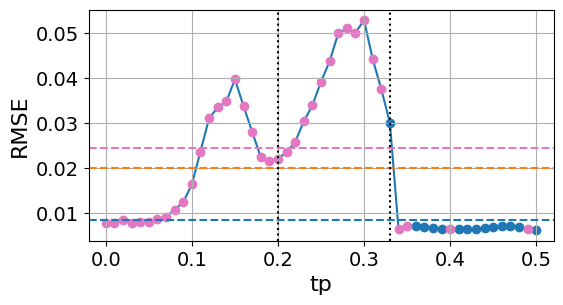

In [28]:
for (run_id, ld, s), group in rmse_df[~rmse_df['contrastive'] & (rmse_df['ld'] == 32) & (rmse_df['s'] == 24000)].groupby(['run_id', 'ld', 's']):
    verteval.plot_rmse_against_tp(group, f'{run_id}_ld{ld}_s{s}', figsize=(6,3), font_size=16, plot_dir=plot_dir, 
                                  plot_name=f'ae_rmse_{run_id}_ld{ld}_s{s}')

mean: 0.06815647241268447, min: 0.0175134435269492, max: 0.1383782627135698
training data only - mean: 0.05598650067169839, min: 0.0175134435269492, max: 0.1222293287601558
test data only - mean: 0.08554214632837888, min: 0.0190059665365078, max: 0.1383782627135698


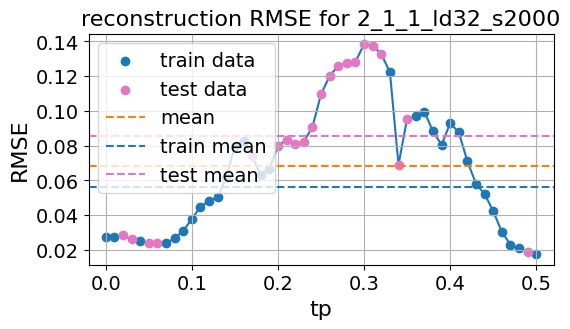

mean: 0.040277421137467385, min: 0.0090315193747978, max: 0.1014380282616174
training data only - mean: 0.028698438605253913, min: 0.0090315193747978, max: 0.0905986799937623
test data only - mean: 0.056818824754915245, min: 0.0096920363975437, max: 0.1014380282616174


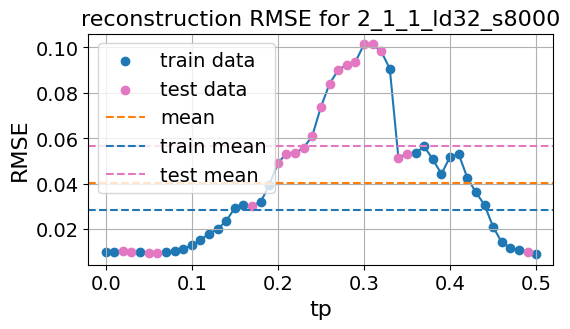

mean: 0.04727399561707828, min: 0.0083833833764575, max: 0.1212743311547443
training data only - mean: 0.033985063781142875, min: 0.0083833833764575, max: 0.1082389475284535
test data only - mean: 0.06625818395412887, min: 0.0087415325092283, max: 0.1212743311547443


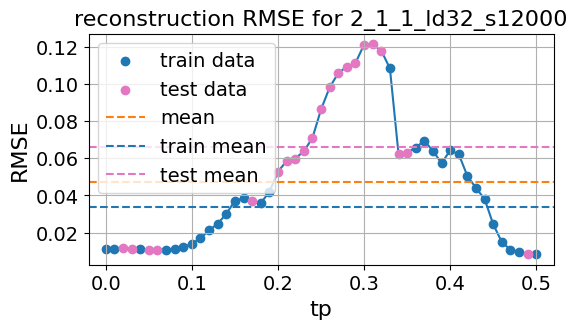

mean: 0.018829849971130682, min: 0.0058888844835213, max: 0.0674691477831666
training data only - mean: 0.009966583433182982, min: 0.0058888844835213, max: 0.0481953859932453
test data only - mean: 0.031491659311055964, min: 0.006229225736502, max: 0.0674691477831666


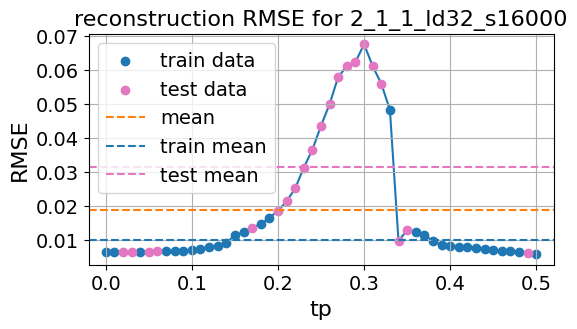

mean: 0.023504360896572443, min: 0.0054835548049802, max: 0.06428741514296
training data only - mean: 0.01582447853219828, min: 0.0054835548049802, max: 0.0501498918183749
test data only - mean: 0.03447562141710695, min: 0.0060597556595962, max: 0.06428741514296


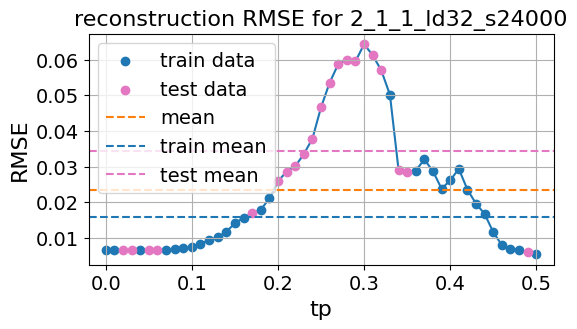

In [ ]:
for (run_id, ld, s), group in rmse_df[(rmse_df['run_id'] == '2_1_1') & (rmse_df['ld'] == 32)].groupby(['run_id', 'ld', 's']):
    verteval.plot_rmse_against_tp(group, f'{run_id}_ld{ld}_s{s}', figsize=(6,3), font_size=16, plot_dir=plot_dir)

reconstruction RMSE for 2_1_1_ld8_s24000
mean: 0.1698668099740209, min: 0.0563486057711932, max: 0.3000015634505707
training data only - mean: 0.14087214403289694, min: 0.0563486057711932, max: 0.2658101576997915
test data only - mean: 0.2112877613184837, min: 0.0621132165191485, max: 0.3000015634505707


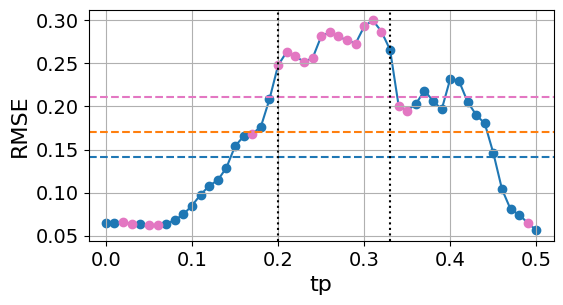

reconstruction RMSE for 2_1_1_ld16_s24000
mean: 0.09762621477913366, min: 0.0241947069982136, max: 0.2133893678188678
training data only - mean: 0.07732067287264986, min: 0.0246249054269442, max: 0.1906810669757207
test data only - mean: 0.12663413178839622, min: 0.0241947069982136, max: 0.2133893678188678


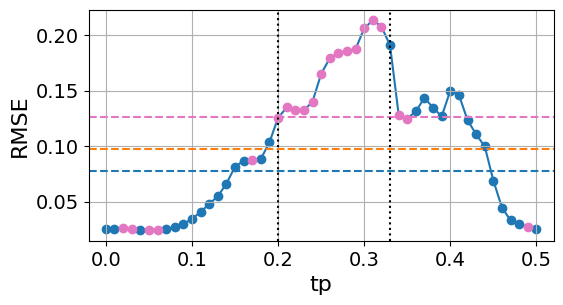

reconstruction RMSE for 2_1_1_ld20_s24000
mean: 0.07475323522414207, min: 0.0184777530350107, max: 0.1753884285875548
training data only - mean: 0.0555143574817175, min: 0.0184777530350107, max: 0.158693618902675
test data only - mean: 0.10223734628474859, min: 0.0192393017482349, max: 0.1753884285875548


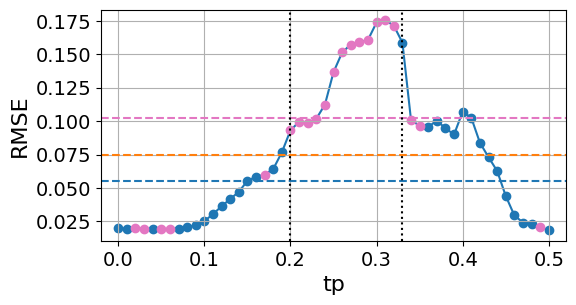

reconstruction RMSE for 2_1_1_ld24_s24000
mean: 0.04687466911381581, min: 0.0066598890367751, max: 0.1212319111065108
training data only - mean: 0.03232695460149508, min: 0.0066598890367751, max: 0.109820575611055
test data only - mean: 0.06765711841713115, min: 0.0079885547434377, max: 0.1212319111065108


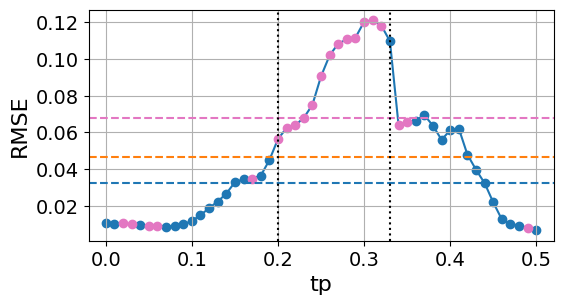

reconstruction RMSE for 2_1_1_ld32_s24000
mean: 0.023504360896572443, min: 0.0054835548049802, max: 0.06428741514296
training data only - mean: 0.01582447853219828, min: 0.0054835548049802, max: 0.0501498918183749
test data only - mean: 0.03447562141710695, min: 0.0060597556595962, max: 0.06428741514296


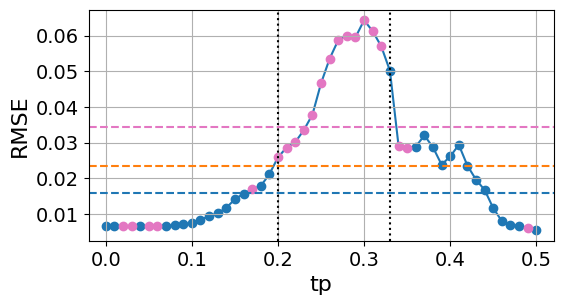

In [29]:
for (run_id, ld, s), group in rmse_df[(rmse_df['run_id'] == '2_1_1') & (rmse_df['s'] == 24000)].groupby(['run_id', 'ld', 's']):
    verteval.plot_rmse_against_tp(group, f'{run_id}_ld{ld}_s{s}', figsize=(6,3), font_size=16, plot_dir=plot_dir)

reconstruction RMSE for 1_2_ld32_s24000
mean: 0.06621499723202705, min: 0.0196729876188259, max: 0.1411463894146165
training data only - mean: 0.06621499723202705, min: 0.0196729876188259, max: 0.1411463894146165


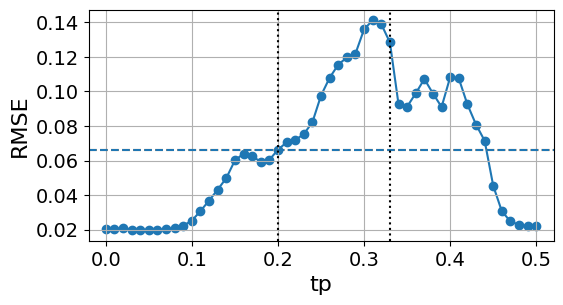

reconstruction RMSE for 2_1_2_ld32_s24000
mean: 0.04314076637809767, min: 0.0097367703815004, max: 0.1144680651146157
training data only - mean: 0.03055552548797525, min: 0.0097367703815004, max: 0.1015223760608776
test data only - mean: 0.06111968193541538, min: 0.0097547245927211, max: 0.1144680651146157


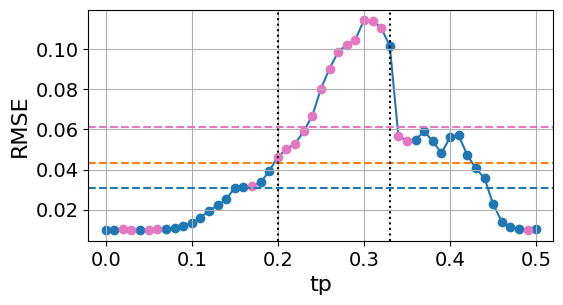

reconstruction RMSE for 2_2_2_ld32_s24000
mean: 0.050307302391825584, min: 0.0211225351602496, max: 0.0908340031611275
training data only - mean: 0.051611620401530764, min: 0.0218633941180148, max: 0.0688014826663395
test data only - mean: 0.04905315045941675, min: 0.0211225351602496, max: 0.0908340031611275


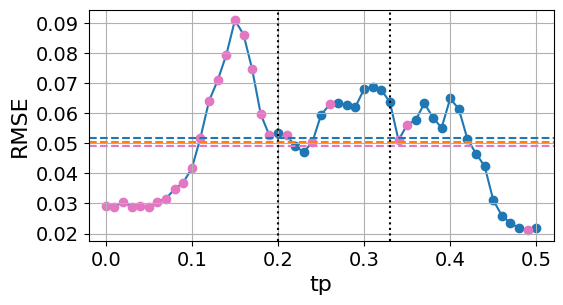

reconstruction RMSE for 2_3_2_ld32_s24000
mean: 0.0670749375226252, min: 0.0209938889883941, max: 0.1295632148579371
training data only - mean: 0.06456942527975959, min: 0.0212229920017746, max: 0.1295632148579371
test data only - mean: 0.0696806702552054, min: 0.0209938889883941, max: 0.1178974209923496


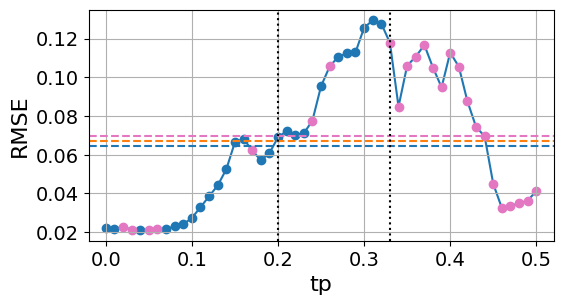

In [30]:
for (run_id, ld, s), group in rmse_df[rmse_df['contrastive'] & (rmse_df['ld'] == 32) & (rmse_df['s'] == 24000)].groupby(['run_id', 'ld', 's']):
    verteval.plot_rmse_against_tp(group, f'{run_id}_ld{ld}_s{s}', figsize=(6,3), font_size=16, plot_dir=plot_dir)

## convergence

In [ ]:
from pathlib import Path

base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results_2/'
folders = sorted([f.name for f in Path(base_path).iterdir() if f.is_dir()])
run_ids = ['1_1', '1_2', '2_1_1', '2_1_2', '2_2_1', '2_2_2', '2_3_1', '2_3_2', '3_1', '3_2', '3_3']  # '2_1_1_nextTp'
labels = []
for f in folders:
    fsplit = f.split('_')
    pref, suff = '_'.join(fsplit[:-1]), fsplit[-1]
    labels.append(f"{pref}, {suff}")
tensorboard_data = vis.get_tensorboard_data(base_path, folders, labels)
tensorboard_data.to_csv('tensorboard_data.csv', index=False)

In [34]:
tensorboard_data = pd.read_csv('tensorboard_data.csv')
tensorboard_data['ld'] = tensorboard_data['run'].str.extract(r'.*ld(\d+)').astype(pd.Int16Dtype()).fillna(32)
tensorboard_data['s'] = tensorboard_data['run'].str.extract(r'.*s(\d+)').astype(pd.Int16Dtype()).fillna(24000)
tensorboard_data['run'] = tensorboard_data['run'].str.split(',').str[0]

tensorboard_stats = vis.get_tensorboard_statistics(tensorboard_data)
tensorboard_stats

wall time [hours]  epochs  min. loss  epoch of min. loss  \
run   ld s                                                                 
1_1   32 24000              40.99   24999   0.000061               22990   
1_2   32 24000              29.99   49999   0.017237               49507   
2_1_1 8  24000              24.41   24999   0.023746               24952   
      16 24000              24.17   24999   0.008373               24995   
      20 24000              24.29   24999   0.004415               24922   
      24 24000              24.36   24999   0.001679               24652   
      32 2000                2.38   24999   0.003523               24904   
         8000                8.31   24999   0.001009               24984   
         12000              12.06   24999   0.001851               24835   
         16000              15.93   24999   0.000074               20349   
         24000              24.40   24999   0.000371               24822   
2_1_2 32 24000              15.42   49999   0.002880               19245   
2_2_1 32 24000              20.24   24999   0.000062               23291   
2_2_2 32 24000              13.57   49999   0.009826               48288   
2_3_1 32 24000              21.33   24999   0.000548               24024   
2_3_2 32 24000              15.52   49999   0.014065               49884   
3_1   32 24000               8.26   24999   0.000077               24280   
3_2   32 24000              12.81   24999   0.000324               24881   
3_3   32 24000              11.27   24999   0.000090               13796   

                max. epochs w/o decrease  epoch of min. loss (10% threshold)  
run   ld s                                                                    
1_1   32 24000                      6539                               16451  
1_2   32 24000                      1136                               40063  
2_1_1 8  24000                       283                               12936  
      16 24000                       364                               16091  
      20 24000                       449                               23341  
      24 24000                      2505                               16547  
      32 2000                        170                               24028  
         8000                        881                               19710  
         12000                       758                               18261  
         16000                      2238                               20168  
         24000                      1834                               18912  
2_1_2 32 24000                      1106                               12852  
2_2_1 32 24000                      7190                               15506  
2_2_2 32 24000                      2211                               36979  
2_3_1 32 24000                      1940                               20555  
2_3_2 32 24000                       652                               41767  
3_1   32 24000                      1685                               23381  
3_2   32 24000                       743                               22936  
3_3   32 24000                      4530                                5430

In [ ]:
# plot run-times
# plot min loss epochs

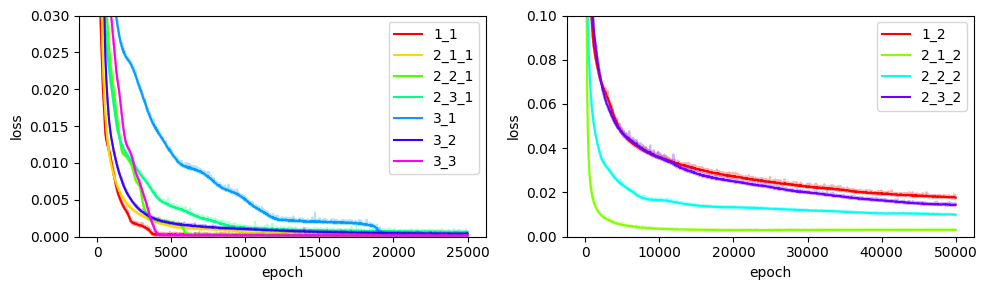

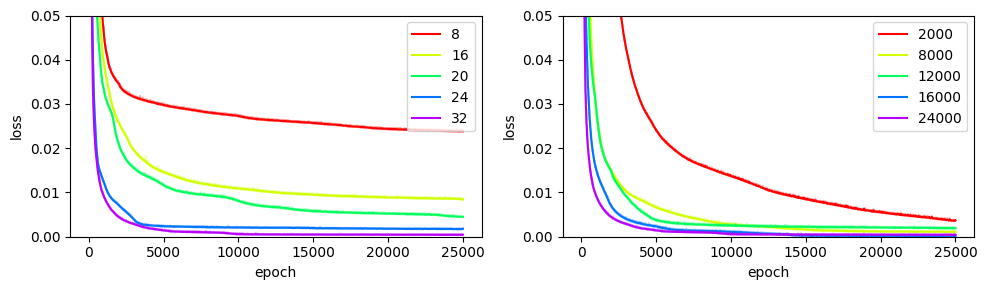

In [45]:
verteval.plot_loss_progress(tensorboard_data.dropna(), y_maxs=(0.03, 0.1, 0.05, 0.05), figsize=(10, 3), log=False)

## compare phase classifier models

In [31]:
classification_df.set_index(['run_id', 'ld', 's'])

,,,f1,conf_mat
run_id,ld,s,,
2_1_1,32,8000,0.958721,"[[1.0, 0.0, 0.0], [0.03445, 0.8989625, 0.06658..."
2_1_2,32,24000,0.969004,"[[1.0, 0.0, 0.0], [0.0272375, 0.92625, 0.04651..."
3_2,32,24000,0.961452,"[[1.0, 0.0, 0.0], [0.032825, 0.9044375, 0.0627..."
2_2_2,32,24000,0.967883,"[[1.0, 0.0, 0.0], [0.0252875, 0.92423125, 0.05..."
2_1_1,8,24000,0.952377,"[[1.0, 0.0, 0.0], [0.0422375, 0.8940875, 0.063..."
2_3_2,32,24000,0.970094,"[[1.0, 0.0, 0.0], [0.01784375, 0.93701875, 0.0..."
3_1,32,24000,0.956281,"[[1.0, 0.0, 0.0], [0.0387, 0.89531875, 0.06598..."
1_1,32,24000,0.956973,"[[1.0, 0.0, 0.0], [0.04370625, 0.8924, 0.06389..."
2_1_1,20,24000,0.963304,"[[1.0, 0.0, 0.0], [0.0316125, 0.91429375, 0.05..."


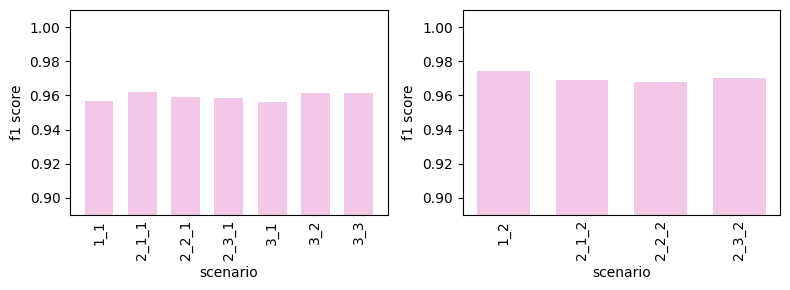

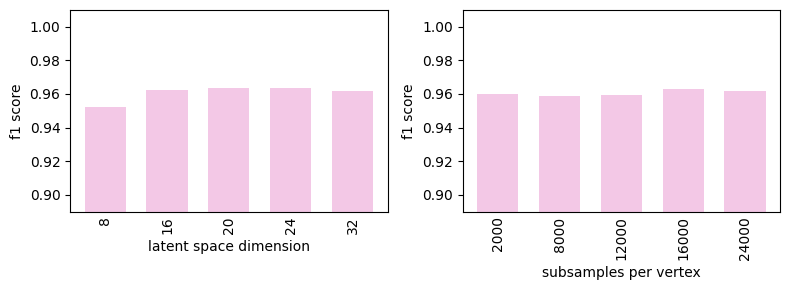

In [34]:
verteval.plot_classification_results(classification_df, figsize=(8, 3))

In [95]:
df = df.reset_index()
df['run_id'] = df['run_id'].str.replace('_', '-')
df

,run_id,ld,s,f1
0,2-1-2,8,24000,0.951040
1,2-1-2,16,24000,0.959179
2,2-1-2,20,24000,0.966148
3,2-1-2,24,24000,0.965585
4,2-1-2,32,24000,0.966148


In [96]:
print(df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lrrr}
\toprule
run_id & ld & s & f1 \\
\midrule
2-1-2 & 8 & 24000 & 0.951 \\
2-1-2 & 16 & 24000 & 0.959 \\
2-1-2 & 20 & 24000 & 0.966 \\
2-1-2 & 24 & 24000 & 0.966 \\
2-1-2 & 32 & 24000 & 0.966 \\
\bottomrule
\end{tabular}



2_1_1_ld32_s8000


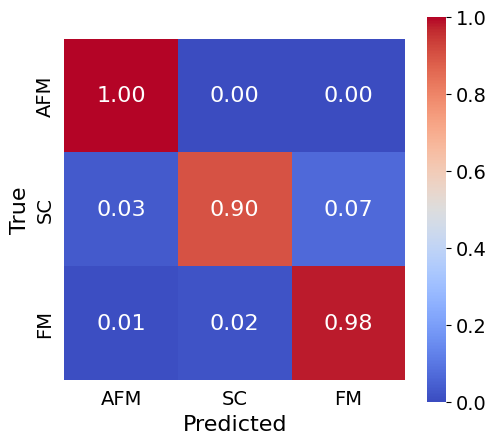

2_1_2_ld32_s24000


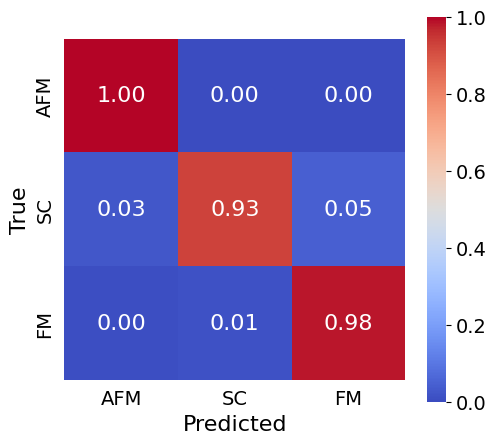

3_2_ld32_s24000


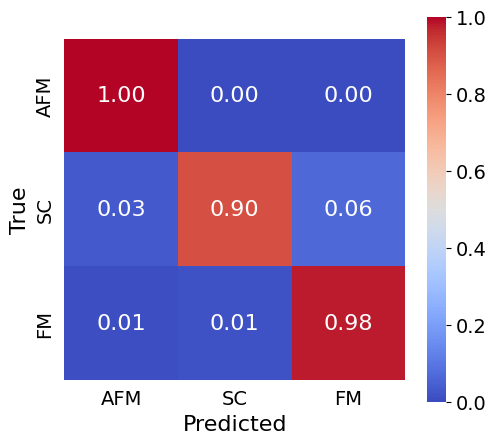

2_2_2_ld32_s24000


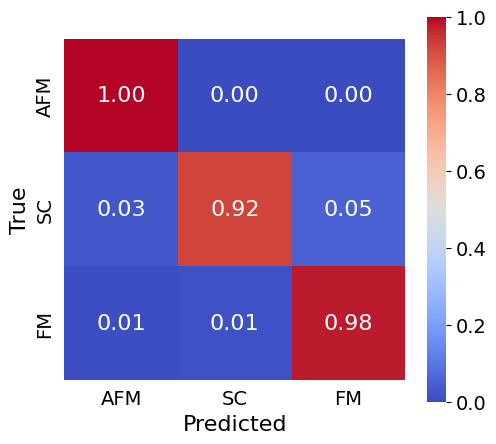

2_1_1_ld8_s24000


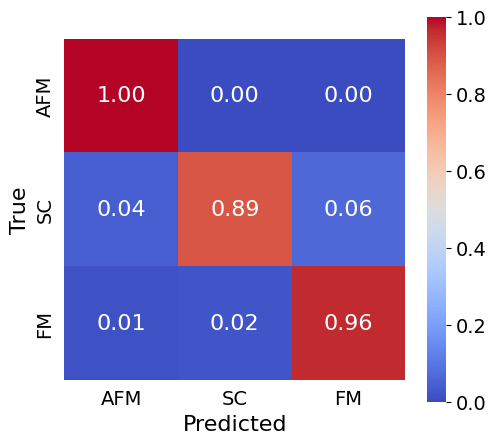

2_3_2_ld32_s24000


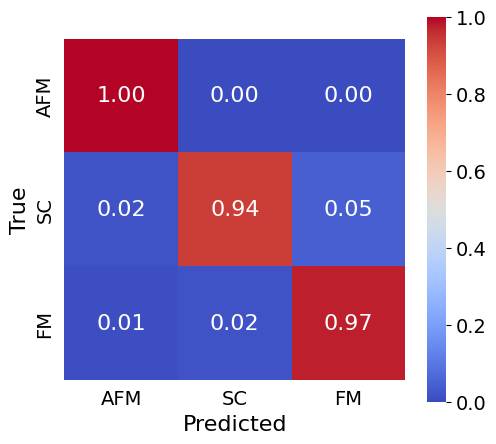

3_1_ld32_s24000


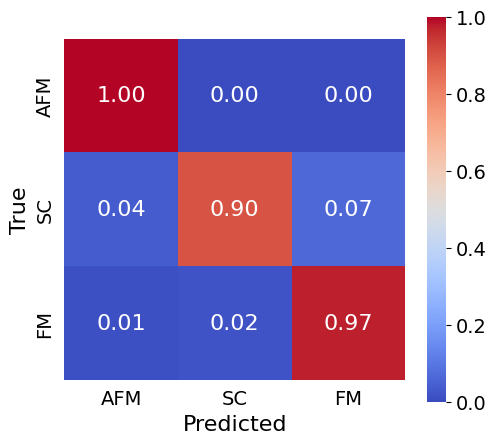

1_1_ld32_s24000


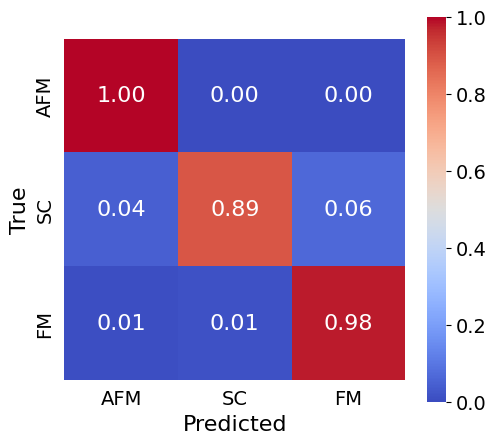

2_1_1_ld20_s24000


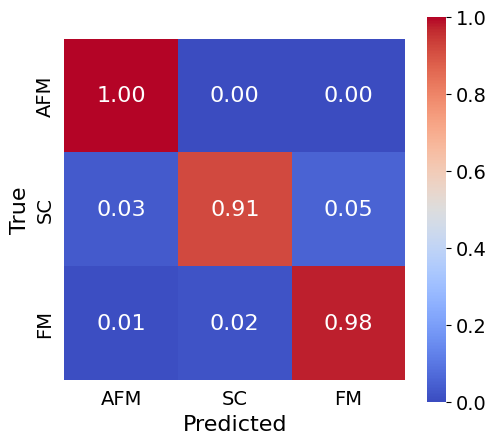

2_2_1_ld32_s24000


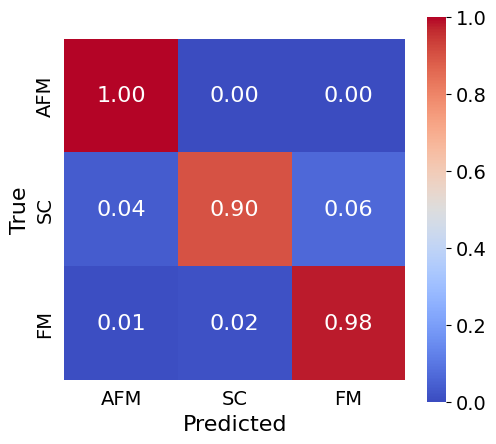

3_3_ld32_s24000


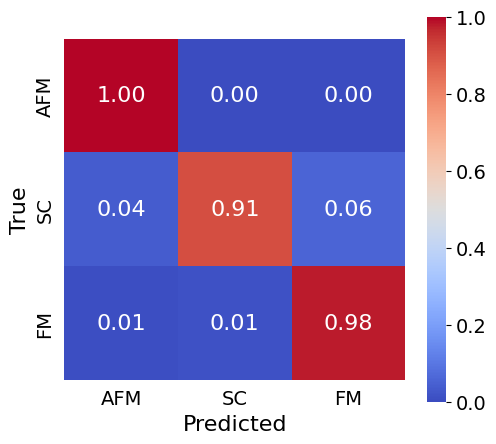

2_1_1_ld32_s24000


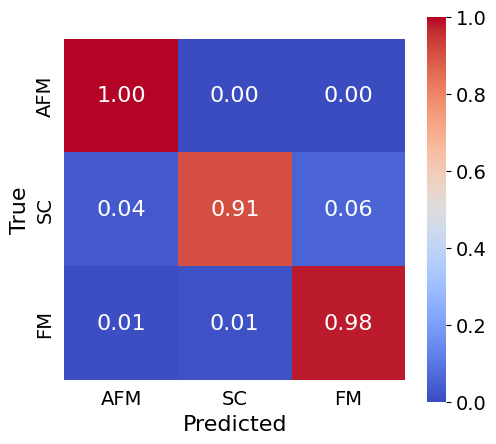

2_1_1_ld32_s12000


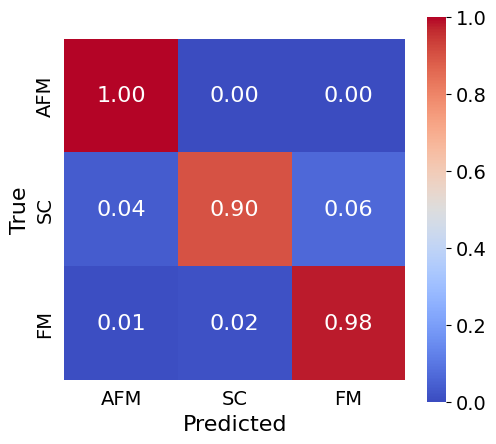

2_1_1_ld32_s16000


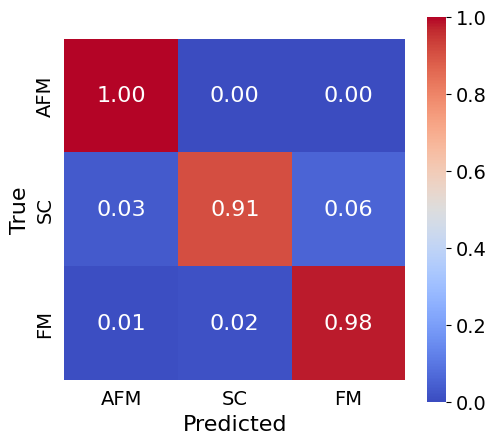

2_1_1_ld24_s24000


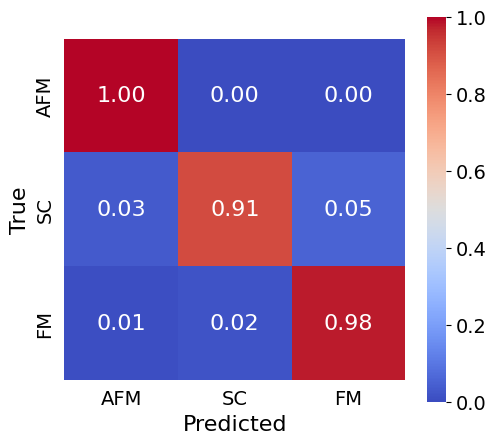

1_2_ld32_s24000


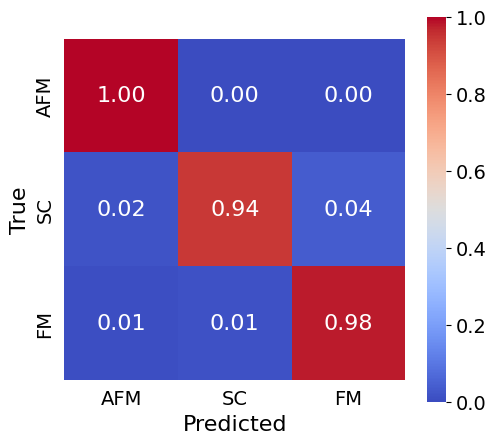

2_1_1_ld32_s2000


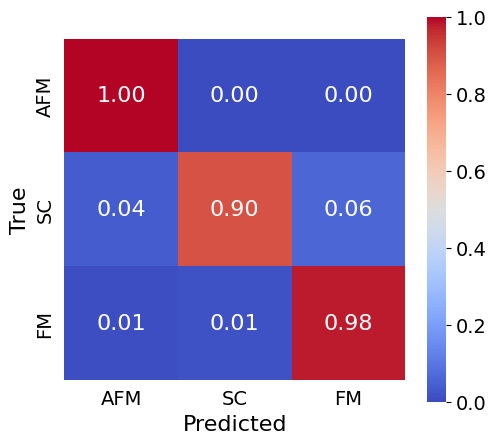

2_1_1_ld16_s24000


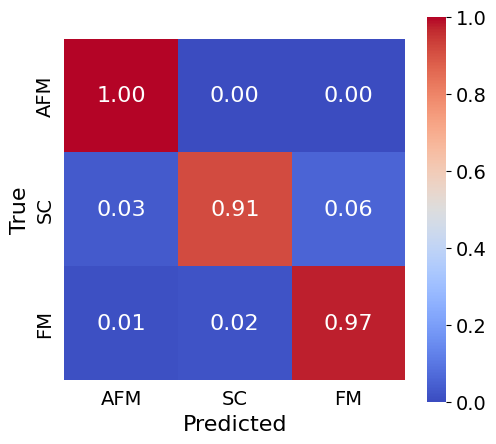

2_3_1_ld32_s24000


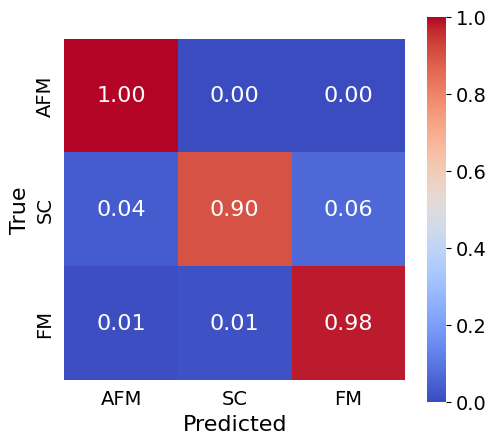

In [35]:
labels = [label.upper() for label in list(AutoEncoderVertexDataset.phase_borders.keys())]
for i, row in classification_df.iterrows():
    vertvis.print_conf_mat(row['conf_mat'], f"{row['run_id']}_ld{row['ld']}_s{row['s']}", labels)

## compare vertex reconstructions

In [2]:
base_path = Path('/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/')
vertex_path_dict = {float(fp.stem[2:6]): fp for fp in data_dir.glob('*.h5')}

In [8]:
# set the run and tp-parameter for which you want to comparte original and reconstruction
runs_to_plot = ['2_1_1_ld8', '2_1_1_ld32']
tp_to_plot = [0.22, 0.33]

vertices = [AutoEncoderVertex24x6Dataset.load_from_file(vertex_path_dict[tp]) for tp in tp_to_plot]
predictions = {run_id: [np.load(base_path / run_id / 'predictions' / (vertex_path_dict[tp].stem + '.npy')) for tp in tp_to_plot] 
               for run_id in runs_to_plot}

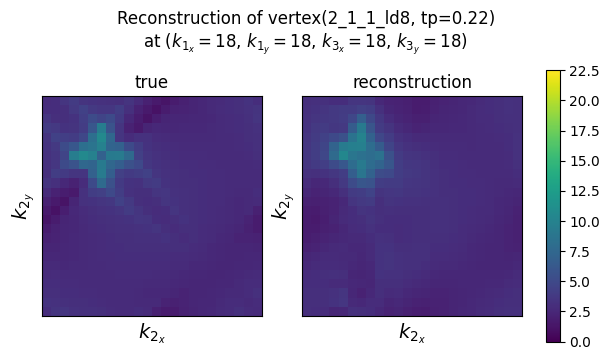

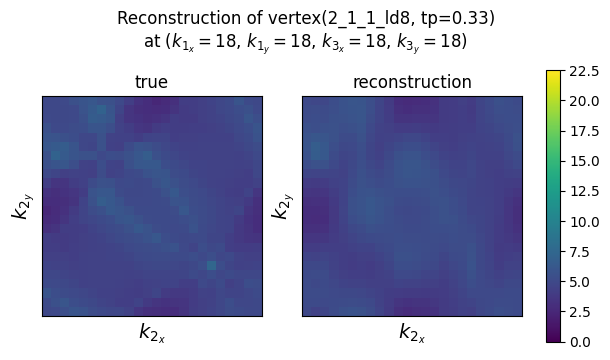

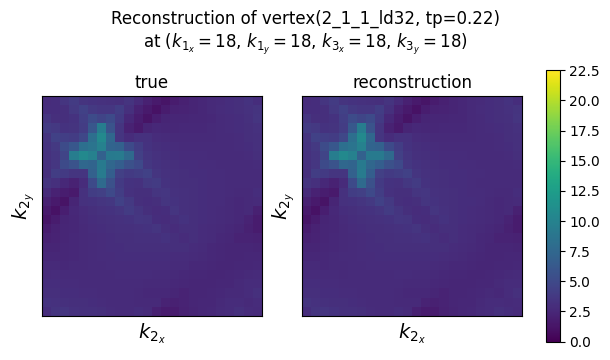

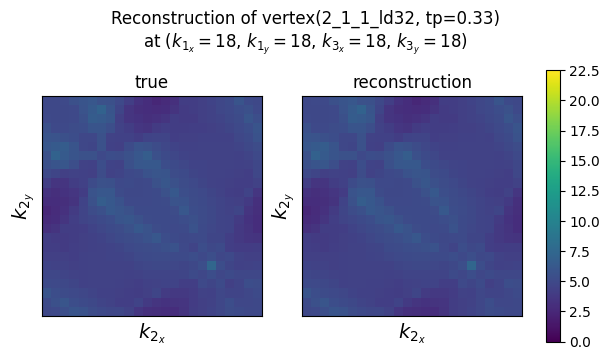

In [9]:
i = 18
axis = 3
nrows, ncols = 1, 2
slice_at = (i, i, i, i)
other_ks = set(range(1,4)) - {(axis + 1) // 2}
params_str = ', '.join([f'$k_{{{k}_{c}}}={sl}$' for (k, c), sl 
                        in zip([(k, c) for k in other_ks for c in ['x', 'y']], slice_at)])

for run_id, preds in predictions.items():
    for tp, true, pred in zip(tp_to_plot, vertices, preds):
        fn = vertex_path_dict[tp].stem
        true_slice = vertvis.get_mat_slice(true, axis, slice_at)
        pred_slice = vertvis.get_mat_slice(pred, axis, slice_at)
        plot_data = {'true': true_slice, 'reconstruction': pred_slice}
        vertvis.plot_compare_grid(plot_data, nrows, ncols, axis, None, figsize=(6, 4), 
                                  title=f'Reconstruction of vertex({run_id}, tp={tp})\nat ({params_str})', vmin=0.0, vmax=22.5)